# 03 — Validação temporal, incerteza e simulação

Cobre: (1) validação por tempo do modelo de preço, (2) cobertura do intervalo conformal **com o asterisco honesto**, (3) os refinamentos da Monte Carlo (Camada 2) e (4) as limitações de dados e o trabalho futuro.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from loteia.model.experimento_geo import (
    montar_dataset_enriquecido, FEATURES_FINAIS_NUM, FEATURES_FINAIS_CAT,
)
from loteia.model.train import split_temporal, treinar_modelo, avaliar, ALVO
from loteia.model.uncertainty import ModeloQuantilico, cobertura_empirica
from loteia.finance.montecarlo import Incerteza, simular_viabilidade

df = montar_dataset_enriquecido()
train, test = split_temporal(df)
anos_tr = sorted(map(int, train.ano.unique()))
anos_te = sorted(map(int, test.ano.unique()))
print(f'treino {len(train):,} (anos {anos_tr}) | teste {len(test):,} (anos {anos_te})')

treino 2,500 (anos [2023, 2024]) | teste 1,325 (anos [2025])


/home/henryque/Documents/JOB/loteIA/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Por que validar por tempo

Embaralhar transações no tempo vaza informação do futuro para o treino e infla a métrica. O corte temporal (treina no passado, testa no futuro) mede o que realmente importa: prever preços de transações que o modelo ainda não viu, no período seguinte.

In [2]:
modelo = treinar_modelo(train, features_num=FEATURES_FINAIS_NUM,
                        features_cat=FEATURES_FINAIS_CAT)
met = avaliar(modelo, test)
print(f'métricas no teste ({anos_te}):', {k: round(v,3) for k,v in met.items()})

métricas no teste ([2025]): {'mae': 1369.301, 'mape_mediana': 0.357, 'r2': 0.252}


## Camada 1 — incerteza com cobertura, e o asterisco

O modelo quantílico conformal (CQR/MAPIE) reporta um intervalo de 80% para o preço/m². A garantia de cobertura do conformal pressupõe **intercambiabilidade** entre calibração e teste — que a validação temporal *deliberadamente viola* (o mercado de 2025 ≠ 2023/2024). Por isso a cobertura empírica no futuro fica **abaixo** da nominal: é um efeito esperado e honesto, não um bug.

In [3]:
mq = ModeloQuantilico(cobertura=0.8, features_num=FEATURES_FINAIS_NUM,
                      features_cat=FEATURES_FINAIS_CAT).fit(train)
cob = cobertura_empirica(mq, test)
pred = mq.predict_intervalo(test)
larg = (pred['preco_m2_sup'] - pred['preco_m2_inf']).median()
print(f'cobertura nominal: 80.0%')
print(f'cobertura empírica no teste ({anos_te}): {cob:.1%}  (sub-cobertura por shift temporal)')
print(f'largura mediana do intervalo: R$ {larg:,.0f}/m²')

INFO:root:The predictions are ill-sorted.


INFO:root:The predictions are ill-sorted.


INFO:root:The predictions are ill-sorted.


INFO:root:The predictions are ill-sorted.


cobertura nominal: 80.0%
cobertura empírica no teste ([2025]): 73.4%  (sub-cobertura por shift temporal)
largura mediana do intervalo: R$ 1,641/m²


## Camada 2 — Monte Carlo e seus refinamentos

A viabilidade é calculada (fluxo de caixa) e a incerteza propagada por simulação. Dois refinamentos tornam as caudas mais realistas:

1. **Estado de mercado comum (`rho`):** acopla preço e velocidade de absorção (mercado quente = preço alto + venda rápida). Aumenta a massa nas caudas conjuntas → distribuição de VPL mais larga, prob. mais conservadora.
2. **Decomposição da incerteza de preço (`frac`):** o intervalo do CQR é preditivo *por lote*; sobre o empreendimento, o ruído idiossincrático se dilui (∝ 1/√n_lotes), restando a incerteza sistemática do nível de preço.

In [4]:
base = dict(n_lotes=100, custo_gleba=3_000_000, meses_obra=12,
  preco_lote=Incerteza(70_000,100_000,130_000),
  custo_infra=Incerteza(2_500_000,3_500_000,5_000_000),
  meses_vendas=Incerteza(12,24,48), taxa_alvo_anual=0.15,
  n_parcelas=12, n_sims=20000, seed=42)
ind = simular_viabilidade(**base)
cor = simular_viabilidade(**base, rho_mercado=0.7)
dec = simular_viabilidade(**base, frac_idiossincratica=0.6)
tab = pd.DataFrame({
  'independente': [ind['prob_viavel'], ind['vpl'].std()],
  '+correl. mercado': [cor['prob_viavel'], cor['vpl'].std()],
  '+decomp. incerteza': [dec['prob_viavel'], dec['vpl'].std()],
}, index=['prob_viavel','std(VPL)']).T
tab['std(VPL)'] = tab['std(VPL)'].round(0)
tab['prob_viavel'] = tab['prob_viavel'].round(3)
print(tab.to_string())

                    prob_viavel   std(VPL)
independente              0.914  1137045.0
+correl. mercado          0.888  1260998.0
+decomp. incerteza        0.970   850404.0


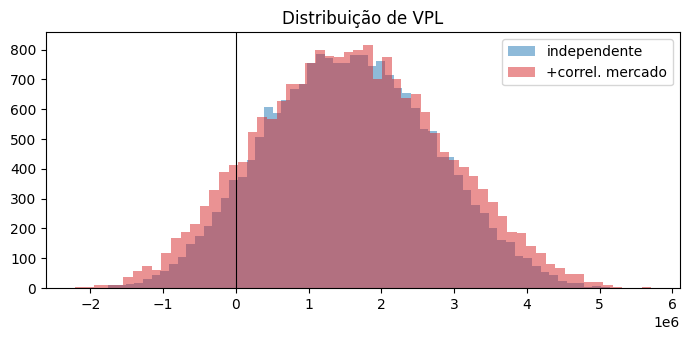

In [5]:
fig, ax = plt.subplots(figsize=(7,3.5))
ax.hist(ind['vpl'], bins=60, alpha=.5, label='independente', color='#1f77b4')
ax.hist(cor['vpl'], bins=60, alpha=.5, label='+correl. mercado', color='#d62728')
ax.axvline(0, color='k', lw=.8); ax.legend(); ax.set_title('Distribuição de VPL')
fig.tight_layout()

## Limitações e trabalho futuro

**Janela de dados (fragilidade nº 1).** A validação usa **2023+2024 como treino contra 2025 como teste** (walk-forward; ao surgir um ano novo, o corte avança e o anterior vira treino). A janela ainda é curta — três anos — porque a Prefeitura publica abertamente só os anos mais recentes de ITBI; anos anteriores a 2023 exigem pedido via LAI ou fontes arquivadas.

**Por que não basta empilhar anos antigos com o cadastro atual.** Verificou-se empiricamente que cada arquivo anual de ITBI embute o **mesmo snapshot atual** do cadastro (99,9% das áreas idênticas entre 2023 e 2024). Usar área/uso atuais para uma transação de 2019 introduz **viés de sobrevivência**: um lote vendido vazio em 2019 e construído desde então apareceria como 'construído' e seria descartado do alvo de terrenos. A correção é o **join com o cadastro TPCL do ano da transação** (GeoSampa Acervo / Base dos Dados–BigQuery), deixado como trabalho futuro por depender de fonte de acesso não automatizável.

**Incerteza de preço.** A cobertura conformal degrada sob shift temporal (quantificado acima); reportar nominal × empírica é a postura honesta.